In [7]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
sim_id = 1991
data_path = f'/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN_BNS/LSST_KN_BNS_{sim_id}/'
head = data_path + f'LSST_KN_BNS_{sim_id}_HEAD.FITS'
phot = data_path + f'LSST_KN_BNS_{sim_id}_PHOT.FITS'

injections = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns/injections_final.csv")

In [35]:
def convert_fluxcal_to_mag(flux, err):
    """Convert fluxcal to magnitude and add magnitude error

    Args:
        df (pd.DataFrame): DataFrame with columns "FLUXCAL" and "FLUXCALERR"
    Returns:
        pd.DataFrame: DataFrame with added "magnitude" and "magnitude error"
    """
    # Convert fluxcal to magnitude
    flux[flux <= 0] = np.nan

    # Compute magnitude; where flux was <= 0, magnitude will be NaN
    mag = -2.5 * np.log10(flux) + 27.5
    magerr = 2.5 / np.log(10) * err / flux
    return mag, magerr

Plotting light curve for SNID 3621 from index 15417 to 19742
Plotting source [81], PEAKMJD: 61336.078125, MJD_EXPLODE: 61334.8444 Index range: 15417-19742


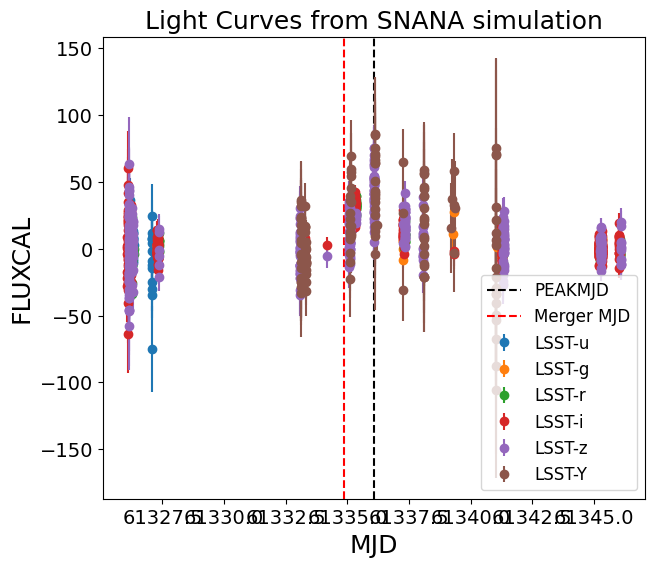

In [11]:
# 打开PHOT.fits文件
phot_hdul = fits.open(phot)
phot_data = phot_hdul[1].data

# 打开HEAD.fits文件，获取每个源的光变曲线索引分界
head_hdul = fits.open(head)
head_data = head_hdul[1].data
start_indices = head_data['PTROBS_MIN']
end_indices = head_data['PTROBS_MAX']

index = np.where(head_data['SNID']=="3621")[0]
start, end = start_indices[index-1][0], end_indices[index][0]
print(f"Plotting light curve for SNID 3621 from index {start} to {end}")

bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-Y']
plt.figure(figsize=(7, 6))
# plt.gca().invert_yaxis()
peakmjd = head_data['PEAKMJD'][index][0]
mjd_explode = injections['mjd_time'][np.where(injections['simulation_id']==sim_id)[0]].values[0]
print(f'Plotting source {index+1}, PEAKMJD: {peakmjd}, MJD_EXPLODE: {mjd_explode} Index range: {start}-{end}')
plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
plt.axvline(x=mjd_explode, color='r', linestyle='--', label="Merger MJD")
source_data = phot_data[start-1:end]  # FITS索引通常从1开始
source_data = source_data[np.where(np.abs(source_data['MJD'] - peakmjd) <= 10)]
mjd = source_data['MJD']
flux = source_data['FLUXCAL']
fluxerr = source_data['FLUXCALERR']
# mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
for band in bands:
    band_mask = source_data['BAND'] == band
    # plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], fmt='o', label=band)
    plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], fmt='o', label=band)
    # plt.errorbar(mjd, flux, yerr=err, fmt='o', label=f'Source {i+1}')
    plt.xlabel('MJD', fontsize=18)
    plt.xticks(fontsize=14)
    plt.ylabel('FLUXCAL', fontsize=18)
    plt.yticks(fontsize=14)
    plt.title('Light Curves from SNANA simulation', fontsize=18)
    plt.legend(fontsize=12)

Plotting source 1, PEAKMJD: 62098.640625, MJD_EXPLODE: 62098.73828125 Index range: 1-16
Plotting source 2, PEAKMJD: 62098.640625, MJD_EXPLODE: 62098.73828125 Index range: 18-42


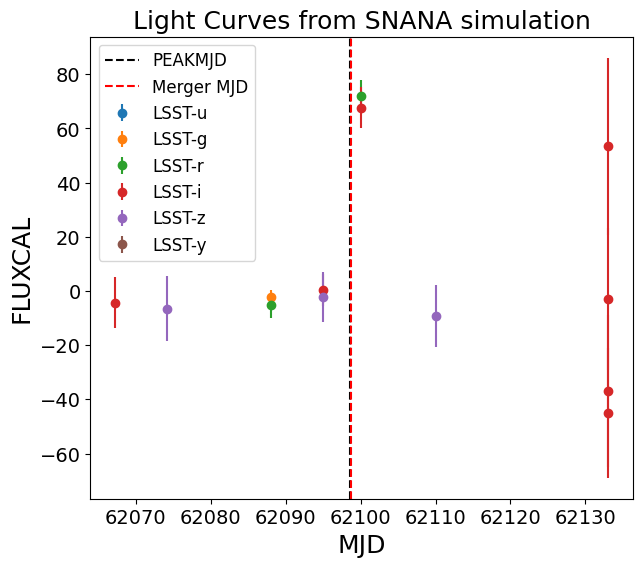

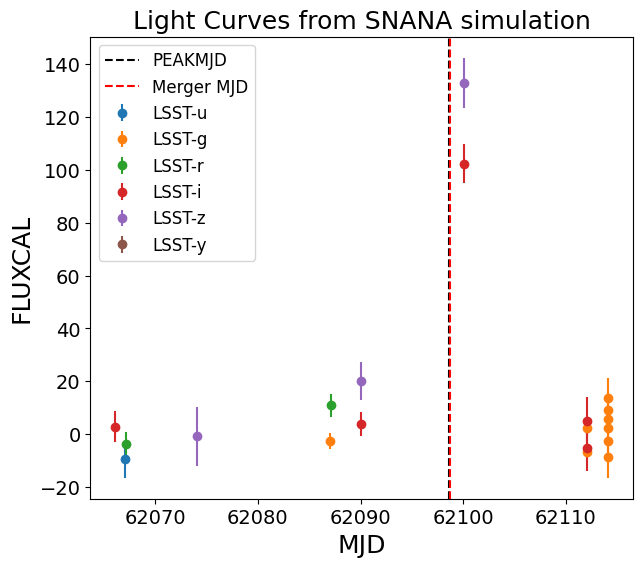

In [ ]:
# 打开PHOT.fits文件
phot_hdul = fits.open(phot)
phot_data = phot_hdul[1].data

# 打开HEAD.fits文件，获取每个源的光变曲线索引分界
head_hdul = fits.open(head)
head_data = head_hdul[1].data
start_indices = head_data['PTROBS_MIN']
end_indices = head_data['PTROBS_MAX']

# 绘制每个源的光变曲线
bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-Y']
for i, (start, end) in enumerate(zip(start_indices, end_indices)):
    if i >=20:
        break
    plt.figure(figsize=(7, 6))
    # plt.gca().invert_yaxis()
    peakmjd = head_data['SIM_PEAKMJD'][i]
    mjd_explode = head_data['SIM_MJD_EXPLODE'][i]
    print(f'Plotting source {i+1}, PEAKMJD: {peakmjd}, MJD_EXPLODE: {mjd_explode} Index range: {start}-{end}')
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    plt.axvline(x=mjd_explode, color='r', linestyle='--', label="Merger MJD")
    source_data = phot_data[start-1:end]  # FITS索引通常从1开始
    mjd = source_data['MJD']
    flux = source_data['FLUXCAL']
    fluxerr = source_data['FLUXCALERR']
    mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
    for band in bands:
        band_mask = source_data['BAND'] == band
        # plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], fmt='o', label=band)
        plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], fmt='o', label=band)
        # plt.errorbar(mjd, flux, yerr=err, fmt='o', label=f'Source {i+1}')
        plt.xlabel('MJD', fontsize=18)
        plt.xticks(fontsize=14)
        plt.ylabel('FLUXCAL', fontsize=18)
        plt.yticks(fontsize=14)
        plt.title('Light Curves from SNANA simulation', fontsize=18)
        plt.legend(fontsize=12)
    
        #plt.savefig(f'/fred/oz016/bgao_kn/data/SNANA_SIM/lc_fig/KNLC_{i+1}.png')
# plt.show()